In [1]:
%load_ext autoreload
%autoreload 2
import sys
sys.path.insert(0, "..")
import matplotlib.pyplot as plt
from src.factors.fama_french import (
    load_public_ff3, load_wrds_ff3, align,
    compare, summary_stats, cumulative_returns,
)

In [2]:
pub = load_public_ff3()
wrds = load_wrds_ff3()
print("Public:", pub.shape, "→", pub.index.min().date(), "to", pub.index.max().date())
print("WRDS:  ", wrds.shape, "→", wrds.index.min().date(), "to", wrds.index.max().date())
pub.head()

Public: (1197, 4) → 1926-07-01 to 2026-03-01
WRDS:   (1197, 5) → 1926-07-01 to 2026-03-01


,mktrf,smb,hml,rf
Date,,,,
1926-07-01,2.89,-2.55,-2.39,0.22
1926-08-01,2.64,-1.14,3.81,0.25
1926-09-01,0.38,-1.36,0.05,0.23
1926-10-01,-3.27,-0.14,0.82,0.32
1926-11-01,2.54,-0.11,-0.61,0.31


In [3]:
pub_a, wrds_a = align(pub, wrds)
cmp = compare(pub_a, wrds_a)
cmp.round(6)

,n_months,mean_abs_diff_pct,max_abs_diff_pct,rmse_pct,correlation
factor,,,,,
hml,1197,0.0,0.0,0.0,1.0
mktrf,1197,0.0,0.0,0.0,1.0
rf,1197,0.0,0.0,0.0,1.0
smb,1197,0.0,0.0,0.0,1.0


In [4]:
stats = summary_stats(pub_a)
stats.round(2)

,n_months,mean_monthly_pct,mean_annual_pct,vol_annual_pct,sharpe_annual
factor,,,,,
hml,1197,0.35,4.26,12.31,0.35
mktrf,1197,0.69,8.22,18.37,0.45
rf,1197,0.27,3.24,0.86,NaN
smb,1197,0.17,2.00,10.91,0.18


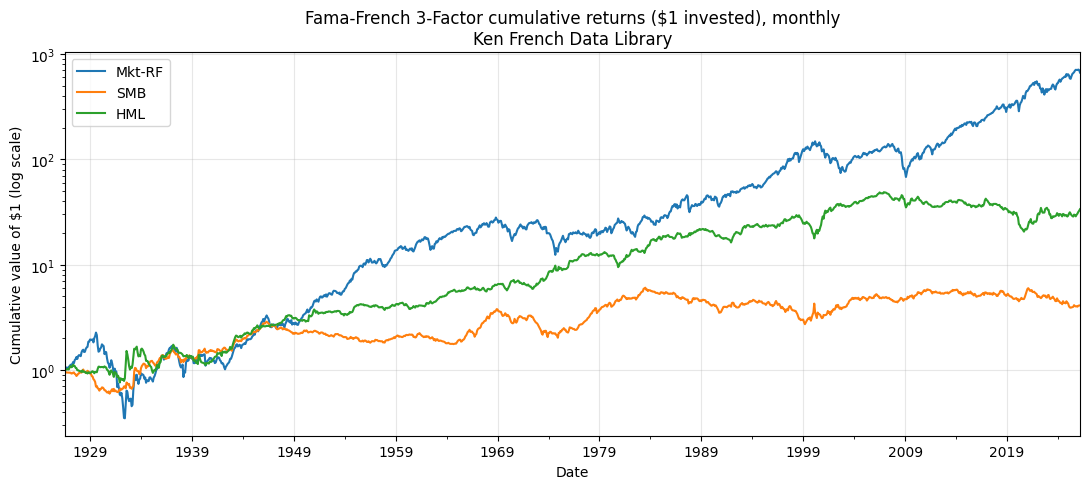

In [5]:
cum = cumulative_returns(pub_a)
fig, ax = plt.subplots(figsize=(11, 5))
cum.plot(ax=ax, logy=True)
ax.set_title("Fama-French 3-Factor cumulative returns ($1 invested), monthly\nKen French Data Library")
ax.set_ylabel("Cumulative value of $1 (log scale)")
ax.set_xlabel("Date")
ax.grid(True, alpha=0.3)
ax.legend(["Mkt-RF", "SMB", "HML"])
plt.tight_layout()
plt.savefig("../figures/ff3_cumulative_returns.png", dpi=150, bbox_inches="tight")
plt.show()